# Phương pháp A

In [ ]:
import polars as pl
import numpy as np
from tqdm import tqdm

df = pl.read_parquet(r"transactions-2025-12.parquet")

result = (
    df.with_columns(
        (((pl.col("updated_date").dt.day() - 1) // 7 + 1)
         .clip(upper_bound=4)
        ).alias("week")
    )
    .group_by(["week", "item_id", "location"])
    .agg(
        pl.col("quantity").sum().alias("total_quantity")
    )
)

groups = result.partition_by(["item_id", "location"], as_dict=True)
errors = []
rows = []

for (item_id, location), pair_df in tqdm(groups.items()):

    pair_df = pair_df.sort("week")

    train = pair_df.filter(pl.col("week") < 4)
    test = pair_df.filter(pl.col("week") == 4)

    if train.height < 2 or test.height == 0:
        continue

    x = train["week"].to_numpy()
    y = train["total_quantity"].to_numpy()

    x_mean = x.mean()
    y_mean = y.mean()

    a = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)
    b = y_mean - a * x_mean

    pred = a * 4 + b
    true = test["total_quantity"][0]

    error = (pred - true) ** 2

    errors.append(error)

    rows.append({
        "item_id": item_id,
        "location": location,
        "pred_week4": pred,
        "true_week4": true,
        "squared_error": error
    })

mse = np.mean(errors)

pred_df = pl.DataFrame(rows)

print("MSE:", mse)
print(pred_df)

yes


100%|██████████| 1167571/1167571 [13:17<00:00, 1463.98it/s]


MSE: 175.17508921668917
shape: (256_118, 5)
┌───────────────┬──────────┬────────────┬────────────┬───────────────┐
│ item_id       ┆ location ┆ pred_week4 ┆ true_week4 ┆ squared_error │
│ ---           ┆ ---      ┆ ---        ┆ ---        ┆ ---           │
│ str           ┆ i64      ┆ f64        ┆ i64        ┆ f64           │
╞═══════════════╪══════════╪════════════╪════════════╪═══════════════╡
│ 2024000000010 ┆ 986      ┆ -10.0      ┆ 37         ┆ 2209.0        │
│ 6697000000002 ┆ 715      ┆ 17.0       ┆ 2          ┆ 225.0         │
│ 5444000000016 ┆ 811      ┆ 10.0       ┆ 4          ┆ 36.0          │
│ 7170000000003 ┆ 390      ┆ 1.0        ┆ 1          ┆ 0.0           │
│ 4603024000002 ┆ 291      ┆ 18.0       ┆ 38         ┆ 400.0         │
│ …             ┆ …        ┆ …          ┆ …          ┆ …             │
│ 6490000000001 ┆ 657      ┆ -1.0       ┆ 5          ┆ 36.0          │
│ 5435000000003 ┆ 469      ┆ 2.5        ┆ 2          ┆ 0.25          │
│ 5427000000008 ┆ 163      ┆ 1.5 

# Plot 1 ví dụ phương án A

Sample pair: ('2024000000010', 986)
shape: (4, 4)
┌──────┬───────────────┬──────────┬────────────────┐
│ week ┆ item_id       ┆ location ┆ total_quantity │
│ ---  ┆ ---           ┆ ---      ┆ ---            │
│ i8   ┆ str           ┆ i32      ┆ i32            │
╞══════╪═══════════════╪══════════╪════════════════╡
│ 1    ┆ 2024000000010 ┆ 986      ┆ 48             │
│ 2    ┆ 2024000000010 ┆ 986      ┆ 30             │
│ 3    ┆ 2024000000010 ┆ 986      ┆ 9              │
│ 4    ┆ 2024000000010 ┆ 986      ┆ 37             │
└──────┴───────────────┴──────────┴────────────────┘


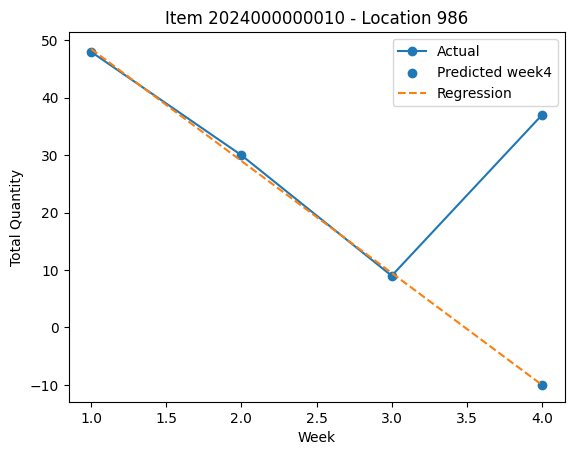

In [ ]:
import matplotlib.pyplot as plt

# tìm 1 group đủ 4 week
sample_pair = None
sample_df = None

for (item_id, location), pair_df in groups.items():

    pair_df = pair_df.sort("week")

    if pair_df.height == 4:
        sample_pair = (item_id, location)
        sample_df = pair_df
        break

print("Sample pair:", sample_pair)
print(sample_df)


# ===== train với week 1-3 =====
train = sample_df.filter(pl.col("week") < 4)

x = train["week"].to_numpy()
y = train["total_quantity"].to_numpy()

x_mean = x.mean()
y_mean = y.mean()

a = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)
b = y_mean - a * x_mean

pred_week4 = a * 4 + b


# ===== plot =====
weeks = sample_df["week"].to_numpy()
actual = sample_df["total_quantity"].to_numpy()

plt.plot(weeks, actual, marker="o", label="Actual")
plt.scatter([4], [pred_week4], label="Predicted week4")

# regression line
x_line = np.array([1,2,3,4])
y_line = a * x_line + b
plt.plot(x_line, y_line, linestyle="--", label="Regression")

plt.xlabel("Week")
plt.ylabel("Total Quantity")
plt.title(f"Item {sample_pair[0]} - Location {sample_pair[1]}")
plt.legend()

plt.show()

# Phương pháp B

In [18]:
import polars as pl
from sklearn.linear_model import LinearRegression
import numpy as np

df = pl.read_parquet(r"transactions-2025-12.parquet")

result = (
    df.with_columns(
        (((pl.col("updated_date").dt.day() - 1) // 7 + 1)
         .clip(upper_bound=4)
        ).alias("week")
    )
    .group_by(["week", "item_id", "location"])
    .agg(
        pl.col("quantity").sum().alias("total_quantity")
    )
)

train = result.filter(pl.col("week") < 4)
test = result.filter(pl.col("week") == 4)

# ===== TRAIN DATA (giữ nguyên toàn bộ điểm) =====
X = train["week"].to_numpy().reshape(-1,1)
y = train["total_quantity"].to_numpy()

model = LinearRegression()
model.fit(X, y)

# ===== PREDICT WEEK 4 =====
pred_week4 = model.predict(np.array([[4]]))[0]

pred_df = test.select(["item_id", "location"]).with_columns(
    pl.lit(pred_week4).alias("pred_week4")
)

# ===== JOIN GROUND TRUTH =====
eval_df = pred_df.join(
    test.select(["item_id", "location", "total_quantity"]),
    on=["item_id", "location"],
    how="inner"
)

# ===== SQUARED ERROR =====
eval_df = eval_df.with_columns(
    ((pl.col("pred_week4") - pl.col("total_quantity")) ** 2).alias("squared_error")
)

print(
    eval_df.select(["item_id", "location", "pred_week4", "total_quantity", "squared_error"])
)

# ===== MSE =====
mse = eval_df["squared_error"].mean()
print("MSE:", mse)

shape: (627_813, 5)
┌───────────────┬──────────┬────────────┬────────────────┬───────────────┐
│ item_id       ┆ location ┆ pred_week4 ┆ total_quantity ┆ squared_error │
│ ---           ┆ ---      ┆ ---        ┆ ---            ┆ ---           │
│ str           ┆ i32      ┆ f64        ┆ i32            ┆ f64           │
╞═══════════════╪══════════╪════════════╪════════════════╪═══════════════╡
│ 1320000000007 ┆ 418      ┆ 2.67366    ┆ 1              ┆ 2.801137      │
│ 2419000000004 ┆ 846      ┆ 2.67366    ┆ 2              ┆ 0.453817      │
│ 0042000000012 ┆ 971      ┆ 2.67366    ┆ 1              ┆ 2.801137      │
│ 6064000000004 ┆ 187      ┆ 2.67366    ┆ 1              ┆ 2.801137      │
│ 4004000000067 ┆ 1142     ┆ 2.67366    ┆ 1              ┆ 2.801137      │
│ …             ┆ …        ┆ …          ┆ …              ┆ …             │
│ 2155000000149 ┆ 1004     ┆ 2.67366    ┆ 3              ┆ 0.106498      │
│ 4553000000003 ┆ 600      ┆ 2.67366    ┆ 2              ┆ 0.453817      │
│ 349


# Nhóm theo Item


In [12]:
import polars as pl
from sklearn.linear_model import LinearRegression
import numpy as np

df = pl.read_parquet(r"transactions-2025-12.parquet")

result = (
    df.with_columns(
        (((pl.col("updated_date").dt.day() - 1) // 7 + 1)
         .clip(upper_bound=4)
        ).alias("week")
    )
    .group_by(["week", "item_id", "location"])
    .agg(
        pl.col("quantity").sum().alias("total_quantity")
    )
)

train = result.filter(pl.col("week") < 4)
test = result.filter(pl.col("week") == 4)

models = {}
predictions = []

groups = train.group_by(["item_id"])

for item_id, group in groups:

    X = group["week"].to_numpy().reshape(-1,1)
    y = group["total_quantity"].to_numpy()

    model = LinearRegression()
    model.fit(X, y)

    models[item_id] = model

    pred = model.predict(np.array([[4]]))[0]

    predictions.append({
        "item_id": item_id[0],   # sửa ở đây
        "pred_week4": pred
    })

pred_df = pl.DataFrame(predictions)



In [8]:
# join prediction với ground truth
eval_df = pred_df.join(
    test.select(["item_id", "location", "total_quantity"]),
    on="item_id",
    how="inner"
)

# tính squared error
eval_df = eval_df.with_columns(
    ((pl.col("pred_week4") - pl.col("total_quantity")) ** 2).alias("squared_error")
)

# in từng dòng
print(
    eval_df.select(["item_id", "location", "pred_week4", "total_quantity", "squared_error"])
)

# sai số trung bình (MSE)
mse = eval_df["squared_error"].mean()
print("MSE:", mse)

shape: (626_101, 5)
┌───────────────┬──────────┬────────────┬────────────────┬───────────────┐
│ item_id       ┆ location ┆ pred_week4 ┆ total_quantity ┆ squared_error │
│ ---           ┆ ---      ┆ ---        ┆ ---            ┆ ---           │
│ str           ┆ i32      ┆ f64        ┆ i32            ┆ f64           │
╞═══════════════╪══════════╪════════════╪════════════════╪═══════════════╡
│ 0007140000002 ┆ 328      ┆ 1.798574   ┆ 1              ┆ 0.637721      │
│ 2482000000004 ┆ 940      ┆ 1.917386   ┆ 2              ┆ 0.006825      │
│ 5444000000007 ┆ 1079     ┆ 2.24694    ┆ 3              ┆ 0.5671        │
│ 7232000000005 ┆ 342      ┆ 1.851975   ┆ 3              ┆ 1.317962      │
│ 2134000000022 ┆ 550      ┆ 1.119323   ┆ 1              ┆ 0.014238      │
│ …             ┆ …        ┆ …          ┆ …              ┆ …             │
│ 0188000000001 ┆ 149      ┆ 1.586614   ┆ 1              ┆ 0.344116      │
│ 5607000000001 ┆ 1107     ┆ 4.087355   ┆ 4              ┆ 0.007631      │
│ 195

# Nhóm theo Location

In [9]:
import polars as pl
from sklearn.linear_model import LinearRegression
import numpy as np

df = pl.read_parquet(r"transactions-2025-12.parquet")

result = (
    df.with_columns(
        (((pl.col("updated_date").dt.day() - 1) // 7 + 1)
         .clip(upper_bound=4)
        ).alias("week")
    )
    .group_by(["week", "item_id", "location"])
    .agg(
        pl.col("quantity").sum().alias("total_quantity")
    )
)

train = result.filter(pl.col("week") < 4)
test = result.filter(pl.col("week") == 4)

models = {}
predictions = []

groups = train.group_by(["location"])

for location, group in groups:

    X = group["week"].to_numpy().reshape(-1,1)
    y = group["total_quantity"].to_numpy()

    model = LinearRegression()
    model.fit(X, y)

    models[location] = model

    pred = model.predict(np.array([[4]]))[0]

    predictions.append({
        "location": location[0],
        "pred_week4": pred
    })

pred_df = pl.DataFrame(predictions)



In [10]:
# join prediction với ground truth
eval_df = pred_df.join(
    test.select(["item_id", "location", "total_quantity"]),
    on="location",
    how="inner"
)

# tính squared error
eval_df = eval_df.with_columns(
    ((pl.col("pred_week4") - pl.col("total_quantity")) ** 2).alias("squared_error")
)

# in từng dòng
print(
    eval_df.select(["item_id", "location", "pred_week4", "total_quantity", "squared_error"])
)

# sai số trung bình (MSE)
mse = eval_df["squared_error"].mean()
print("MSE:", mse)

shape: (624_081, 5)
┌───────────────┬──────────┬────────────┬────────────────┬───────────────┐
│ item_id       ┆ location ┆ pred_week4 ┆ total_quantity ┆ squared_error │
│ ---           ┆ ---      ┆ ---        ┆ ---            ┆ ---           │
│ str           ┆ i64      ┆ f64        ┆ i32            ┆ f64           │
╞═══════════════╪══════════╪════════════╪════════════════╪═══════════════╡
│ 4398000000001 ┆ 1000     ┆ 2.794249   ┆ 2              ┆ 0.630832      │
│ 2017000000036 ┆ 1289     ┆ 2.977388   ┆ 11             ┆ 64.362304     │
│ 7490000000001 ┆ 191      ┆ 3.760471   ┆ 2              ┆ 3.099259      │
│ 0028020000001 ┆ 587      ┆ 2.955509   ┆ 7              ┆ 16.357908     │
│ 3389000000312 ┆ 585      ┆ 2.425927   ┆ 1              ┆ 2.033269      │
│ …             ┆ …        ┆ …          ┆ …              ┆ …             │
│ 2278000000026 ┆ 385      ┆ 2.944018   ┆ 1              ┆ 3.779206      │
│ 3514000000193 ┆ 627      ┆ 2.701133   ┆ 1              ┆ 2.893853      │
│ 751